# ESOL EDA — locking in modeling decisions

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid")

FIG_DIR = Path("../results/esol_eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path("../data/processed/esol_clean.csv")
df = pd.read_csv(DATA_PATH)
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
assert df["mol"].notna().all(), "Some SMILES failed to parse"
print(f"Loaded {len(df)} molecules")
df.head()

Loaded 1128 molecules


,smiles,target_solubility,mol
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,<rdkit.Chem.rdchem.Mol object at 0x120001af0>
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,<rdkit.Chem.rdchem.Mol object at 0x120001b60>
2,CC(C)=CCCC(C)=CC(=O),-2.06,<rdkit.Chem.rdchem.Mol object at 0x120001bd0>
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,<rdkit.Chem.rdchem.Mol object at 0x120001c40>
4,c1ccsc1,-1.33,<rdkit.Chem.rdchem.Mol object at 0x120001cb0>


## 1. Target distribution → loss & metric choice

Checking: roughly normal or skewed? outliers? bounded? This decides whether plain MSE/L1 is appropriate or whether we need a transform / robust loss.

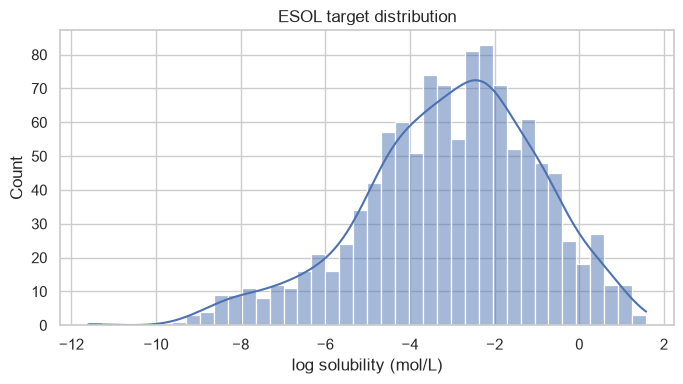

mean=-3.05  std=2.10
min=-11.60  max=1.58
skew=-0.49  kurtosis=0.19


In [2]:
target = df["target_solubility"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(target, bins=40, kde=True, ax=ax)
ax.set_xlabel("log solubility (mol/L)")
ax.set_title("ESOL target distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", dpi=150)
plt.show()

print(f"mean={target.mean():.2f}  std={target.std():.2f}")
print(f"min={target.min():.2f}  max={target.max():.2f}")
print(f"skew={target.skew():.2f}  kurtosis={target.kurt():.2f}")

## 2. Dataset size & target range → model capacity

~1,100 molecules is small. Combined with the target range above, this rules out large models and points to a compact GNN with heavy regularization.

In [3]:
print(f"Number of molecules: {len(df)}")
print(f"Target range: [{target.min():.2f}, {target.max():.2f}]  (span={target.max() - target.min():.2f})")
print(f"Target std: {target.std():.2f}")

Number of molecules: 1128
Target range: [-11.60, 1.58]  (span=13.18)
Target std: 2.10


## 3. Molecule size distribution → architecture feasibility

Checking max atoms/bonds (batching cost) and flagging single-atom or disconnected molecules, which need a guard in the featurizer/graph builder.

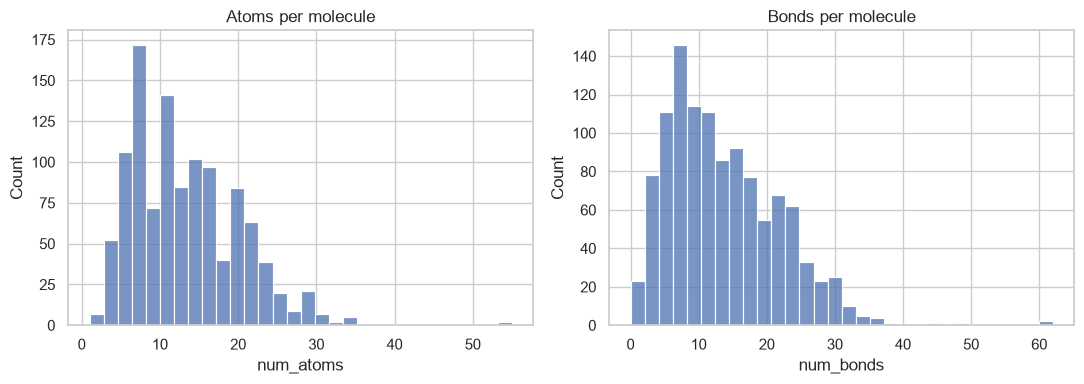

Atoms: min=1 max=55 mean=13.3
Bonds: min=0 max=62 mean=13.7
Single-atom molecules: 1
Disconnected molecules (>1 fragment): 0


In [4]:
df["num_atoms"] = df["mol"].apply(lambda m: m.GetNumAtoms())
df["num_bonds"] = df["mol"].apply(lambda m: m.GetNumBonds())
df["num_fragments"] = df["mol"].apply(lambda m: len(Chem.GetMolFrags(m)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["num_atoms"], bins=30, ax=axes[0])
axes[0].set_title("Atoms per molecule")
sns.histplot(df["num_bonds"], bins=30, ax=axes[1])
axes[1].set_title("Bonds per molecule")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_molecule_size.png", dpi=150)
plt.show()

print(f"Atoms: min={df['num_atoms'].min()} max={df['num_atoms'].max()} mean={df['num_atoms'].mean():.1f}")
print(f"Bonds: min={df['num_bonds'].min()} max={df['num_bonds'].max()} mean={df['num_bonds'].mean():.1f}")
print(f"Single-atom molecules: {(df['num_atoms'] == 1).sum()}")
print(f"Disconnected molecules (>1 fragment): {(df['num_fragments'] > 1).sum()}")

## 4. Element & bond-type frequency → feature vocabulary check

Cross-checking observed elements/bond types against the one-hot vocab already chosen in `src/config/features.py`.

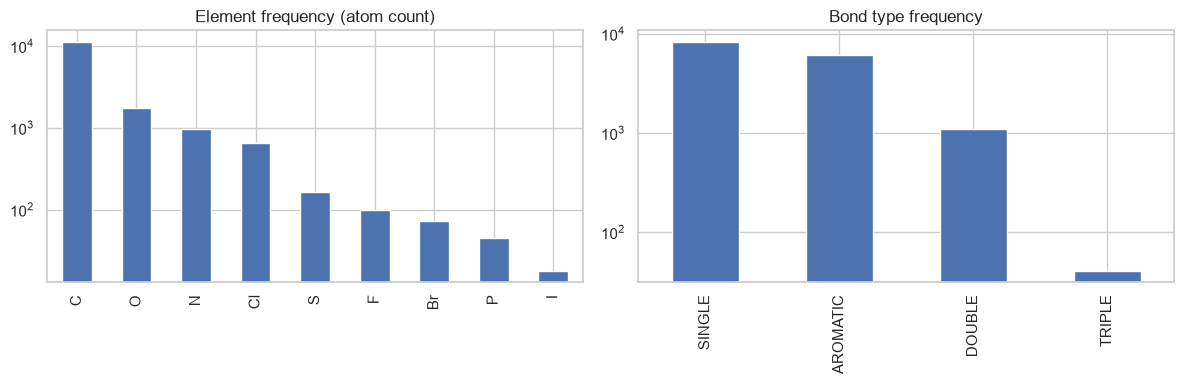

Element counts:
C     11207
O      1768
N       970
Cl      645
S       166
F       100
Br       72
P        45
I        18
dtype: int64

Bond type counts:
SINGLE      8255
AROMATIC    6041
DOUBLE      1091
TRIPLE        41
dtype: int64

Current element vocab: ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'other']
Elements NOT in vocab (would fall into 'other'): []


In [5]:
element_counts = Counter()
bondtype_counts = Counter()
for m in df["mol"]:
    for atom in m.GetAtoms():
        element_counts[atom.GetSymbol()] += 1
    for bond in m.GetBonds():
        bondtype_counts[str(bond.GetBondType())] += 1

elem_series = pd.Series(element_counts).sort_values(ascending=False)
bond_series = pd.Series(bondtype_counts).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
elem_series.plot(kind="bar", ax=axes[0])
axes[0].set_title("Element frequency (atom count)")
axes[0].set_yscale("log")
bond_series.plot(kind="bar", ax=axes[1])
axes[1].set_title("Bond type frequency")
axes[1].set_yscale("log")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_element_bond_frequency.png", dpi=150)
plt.show()

print("Element counts:")
print(elem_series)
print("\nBond type counts:")
print(bond_series)

from src.config.features import ATOM_SYMBOLS

uncovered_elements = [e for e in element_counts if e not in ATOM_SYMBOLS]
print(f"\nCurrent element vocab: {ATOM_SYMBOLS}")
print(f"Elements NOT in vocab (would fall into 'other'): {uncovered_elements}")

## 5. Scaffold analysis (Bemis-Murcko) → split strategy

Clustering molecules by their core ring scaffold. If scaffolds are concentrated (few scaffolds cover many molecules), a random split leaks near-duplicate structures between train/test and inflates the score — evidence for a scaffold split.

Molecules: 1128
Unique scaffolds: 269  (23.8% of molecules)
Scaffolds appearing exactly once: 194 (72.1% of scaffolds)
Top 10 scaffolds cover 722 molecules (64.0% of dataset)


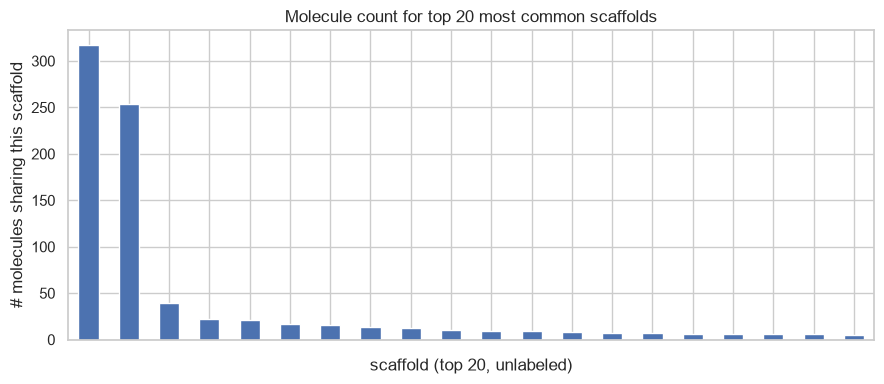

In [6]:
def get_scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


df["scaffold"] = df["mol"].apply(get_scaffold_smiles)
scaffold_counts = df["scaffold"].value_counts()

n_molecules = len(df)
n_scaffolds = df["scaffold"].nunique()
singleton_scaffolds = (scaffold_counts == 1).sum()
top10_coverage = scaffold_counts.head(10).sum()

print(f"Molecules: {n_molecules}")
print(f"Unique scaffolds: {n_scaffolds}  ({n_scaffolds / n_molecules:.1%} of molecules)")
print(f"Scaffolds appearing exactly once: {singleton_scaffolds} ({singleton_scaffolds / n_scaffolds:.1%} of scaffolds)")
print(f"Top 10 scaffolds cover {top10_coverage} molecules ({top10_coverage / n_molecules:.1%} of dataset)")

fig, ax = plt.subplots(figsize=(9, 4))
scaffold_counts.head(20).plot(kind="bar", ax=ax)
ax.set_title("Molecule count for top 20 most common scaffolds")
ax.set_ylabel("# molecules sharing this scaffold")
ax.set_xticklabels([])
ax.set_xlabel("scaffold (top 20, unlabeled)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_scaffold_concentration.png", dpi=150)
plt.show()

## 6. Baseline descriptor correlation → is a GNN even needed?

Computing cheap RDKit descriptors (MW, LogP, H-bond donors/acceptors, TPSA) and checking correlation with solubility, then fitting a plain linear baseline. This is the number the GNN has to beat to justify its complexity.

Correlation with target_solubility:
logp          -0.827918
mol_weight    -0.640189
h_donors       0.209429
tpsa           0.123210
h_acceptors    0.049634
Name: target_solubility, dtype: float64


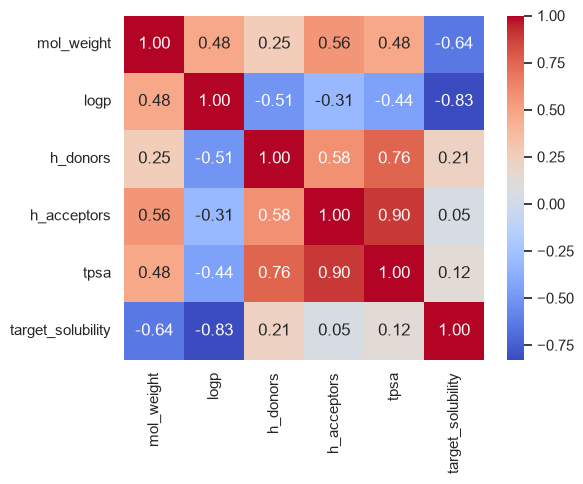


Baseline linear model (5 descriptors, random 80/20 split): R²=0.742  RMSE=1.105


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df["mol_weight"] = df["mol"].apply(Descriptors.MolWt)
df["logp"] = df["mol"].apply(Crippen.MolLogP)
df["h_donors"] = df["mol"].apply(rdMolDescriptors.CalcNumHBD)
df["h_acceptors"] = df["mol"].apply(rdMolDescriptors.CalcNumHBA)
df["tpsa"] = df["mol"].apply(rdMolDescriptors.CalcTPSA)

descriptor_cols = ["mol_weight", "logp", "h_donors", "h_acceptors", "tpsa"]
corr = df[descriptor_cols + ["target_solubility"]].corr()["target_solubility"].drop("target_solubility")
print("Correlation with target_solubility:")
print(corr.sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df[descriptor_cols + ["target_solubility"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_descriptor_correlation.png", dpi=150)
plt.show()

X = df[descriptor_cols].values
y = df["target_solubility"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline = LinearRegression().fit(X_train, y_train)
preds = baseline.predict(X_test)
r2 = r2_score(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
print(f"\nBaseline linear model (5 descriptors, random 80/20 split): R²={r2:.3f}  RMSE={rmse:.3f}")

## Summary — decisions locked

1. **Target distribution.** Mean -3.05, std 2.10, range [-11.60, 1.58], skew -0.49, kurtosis 0.19 this means roughly Gaussian, mild left skew, no extreme outliers or bounding.
   > **Decision: plain MSE (or L1) loss, no transform needed.**

2. **Dataset size.** 1,128 molecules, target span 13.18 log units.
      > **Decision: keep the model small (low hundred-thousands of params) with heavy regularization — this is far too little data for a large model.**

3. **Molecule size.** Atoms: min 1, max 55, mean 13.3. Bonds: min 0, max 62, mean 13.7. 0 disconnected molecules, 1 single-atom molecule (0 bonds).
      > **Decision: a GNN is computationally trivial here (max 55 atoms, cheap batching). The single-atom/0-bond case is already guarded in `featurizer.py` (empty `edge_index`/`edge_attr` branch), so no dataset filtering is required.**

4. **Element & bond-type frequency.** Observed elements: C, O, N, Cl, S, F, Br, P, I. Observed bond types: SINGLE, AROMATIC, DOUBLE, TRIPLE.
   > **Decision: the vocab already in `src/config/features.py` (`ATOM_SYMBOLS`, `BOND_TYPES`) covers every element/bond type seen in ESOL exactly — no gaps, `other` bucket exists purely as a safety net for future UI input.**

5. **Scaffold analysis.** 269 unique Bemis-Murcko scaffolds across 1,128 molecules (23.8% unique-scaffold ratio); 72.1% of scaffolds appear exactly once, but the top 10 scaffolds alone cover 64.0% of the whole dataset.
   > **Decision: scaffolds are heavily concentrated → a random split would leak near-identical structures between train/test and inflate the score. Use a scaffold split for the train/val/test division (next step).**

6. **Baseline descriptor correlation.** LogP correlates -0.83 with solubility (dominant single predictor), MolWt -0.64, H-donors +0.21, TPSA +0.12, H-acceptors +0.05. A 5-descriptor linear regression on a random 80/20 split gets **R² = 0.742, RMSE = 1.105**.
   > **Decision: this is the bar the GNN has to clear to justify itself.** Note this baseline used a random split — worth re-measuring once the scaffold split exists, since that's a harder, more honest comparison.